In [1]:
import anndata as ad
import numpy as np
import pandas as pd
import SDP_miRNA.dataset
import SDP_miRNA.optimization
import SDP_miRNA.optimization_MOSEK
import SDP_miRNA.correlation
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import scanpy as sc

In [2]:
rng = np.random.default_rng(423)

In [ ]:
# load pcRNA
adata_pcRNA = ad.read_h5ad("../HEK293T/TotalX_HEK293T_pcRNA.h5ad")

# load miRNA
adata_miRNA = ad.read_h5ad("../HEK293T/TotalX_HEK293T_miRNA.h5ad")

# load capture
beta = np.loadtxt("../HEK293T/TotalX_HEK293T_capture.txt")

## Cell cycle scoring

In [31]:
adata_cc = adata_pcRNA.copy()
adata_cc.var_names = adata_cc.var['GeneName'].values.tolist()
adata_cc

AnnData object with n_obs × n_vars = 11945 × 10307
    var: 'gene_ids', 'feature_types', 'genome', 'GeneName', 'gene_id', 'biotype'
    layers: None (.X)

In [36]:
# load cell cycle genes
cell_cycle_genes = [x.strip() for x in open("../../Latent-Experiments/R-Notebooks/regev_lab_cell_cycle_genes.txt")]

# Split into 2 lists
s_genes = cell_cycle_genes[:43]
g2m_genes = cell_cycle_genes[43:]

# subset to observed
s_genes_data = [x for x in s_genes if x in adata_cc.var_names]
g2m_genes_data = [x for x in g2m_genes if x in adata_cc.var_names]
cell_cycle_genes_data = [x for x in cell_cycle_genes if x in adata_cc.var_names]


print(f"{len(s_genes_data)} / {len(s_genes)}")
print(f"{len(g2m_genes_data)} / {len(g2m_genes)}")

42 / 43
52 / 54


In [33]:
# normalize and log transform
sc.pp.normalize_total(adata_cc, target_sum=1e4)
sc.pp.log1p(adata_cc)

In [34]:
sc.tl.score_genes_cell_cycle(adata_cc, s_genes=s_genes_data, g2m_genes=g2m_genes_data)

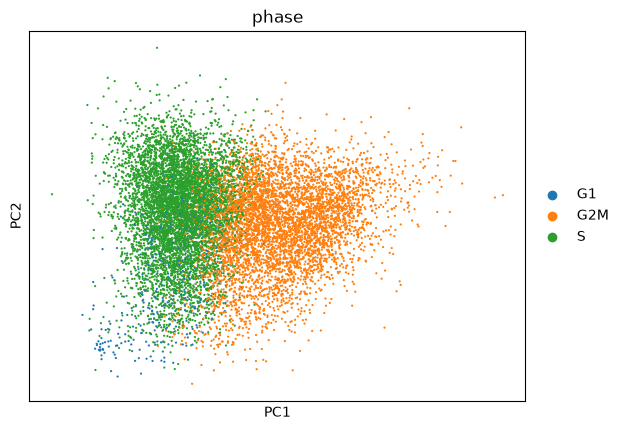

In [37]:
adata_cc_genes = adata_cc[:, cell_cycle_genes_data].copy()
sc.tl.pca(adata_cc_genes)
sc.pl.pca(adata_cc_genes, color="phase")

In [48]:
adata_cc.obs['phase'].value_counts()

phase
S      6285
G2M    5217
G1      443
Name: count, dtype: int64

## Inference

In [62]:
# choose miRNA
miRNA = "MIR4709"

# choose mRNA: negatively correlated using all cells
names_neg = np.array(['MIR4709', 'LRBA', 'PWWP2A', 'IMMP2L', 'WDR76', 'ZNF557'])

# number of targets
T = len(names_neg)

In [63]:
# subset adata
adata_neg = adata_pcRNA[:, adata_pcRNA.var['GeneName'].isin(names_neg)]
adata_miRNA_chosen = adata_miRNA[:, adata_miRNA.var['GeneName'] == miRNA]

# combine 
adata_chosen = ad.concat([adata_miRNA_chosen, adata_neg], axis=1)

In [64]:
# split cells by phase
adata_chosen_G1 = adata_chosen[adata_cc.obs['phase'] == "G1", :]
adata_chosen_S = adata_chosen[adata_cc.obs['phase'] == "S", :]
adata_chosen_G2M = adata_chosen[adata_cc.obs['phase'] == "G2M", :]

In [65]:
# split capture by phase
beta_G1 = beta[adata_cc.obs['phase'] == "G1"]
beta_S = beta[adata_cc.obs['phase'] == "S"]
beta_G2M = beta[adata_cc.obs['phase'] == "G2M"]

In [66]:
# select all gene pairs: no repeats
Is, Js = np.triu_indices(T, k=1)
gene_queries = [
    [[int(i)], [int(j)]] for i, j in zip(Is, Js)
]

# construct dataset
SDP_data = SDP_miRNA.dataset.Dataset()
SDP_data_G1 = SDP_miRNA.dataset.Dataset()
SDP_data_S = SDP_miRNA.dataset.Dataset()
SDP_data_G2M = SDP_miRNA.dataset.Dataset()
SDP_data.construct_dataset_adata(adata_chosen, adata_chosen, beta, gene_queries)
SDP_data_G1.construct_dataset_adata(adata_chosen_G1, adata_chosen_G1, beta_G1, gene_queries)
SDP_data_S.construct_dataset_adata(adata_chosen_S, adata_chosen_S, beta_S, gene_queries)
SDP_data_G2M.construct_dataset_adata(adata_chosen_G2M, adata_chosen_G2M, beta_G2M, gene_queries)

# bootstrap
SDP_data.bootstrap(d=3)
SDP_data_G1.bootstrap(d=3)
SDP_data_S.bootstrap(d=3)
SDP_data_G2M.bootstrap(d=3)

  0%|          | 0/1 [00:00<?, ?it/s]

100%|██████████| 1/1 [00:00<00:00,  4.55it/s]


In [67]:
# model free independence test
MF_ind = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data, d=3)
MF_ind.optimized_construction = True
MF_ind.analyse_dataset()

MF_ind_G1 = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data_G1, d=3)
MF_ind_G1.optimized_construction = True
MF_ind_G1.analyse_dataset()

MF_ind_S = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data_S, d=3)
MF_ind_S.optimized_construction = True
MF_ind_S.analyse_dataset()

MF_ind_G2M = SDP_miRNA.optimization.ModelFreeOptimization(SDP_data_G2M, d=3)
MF_ind_G2M.optimized_construction = True
MF_ind_G2M.analyse_dataset()

  0%|          | 0/15 [00:00<?, ?it/s]

100%|██████████| 15/15 [00:00<00:00, 154.01it/s]


In [68]:
# model free interacting H&R
MF_int = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data, d=3)
MF_int.analyse_dataset()

MF_int_G1 = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data_G1, d=3)
MF_int_G1.analyse_dataset()

MF_int_S = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data_S, d=3)
MF_int_S.analyse_dataset()

MF_int_G2M = SDP_miRNA.optimization_MOSEK.MOSEKModelFreeInteracting(SDP_data_G2M, d=3)
MF_int_G2M.analyse_dataset()

100%|██████████| 15/15 [00:05<00:00,  2.58it/s]


In [69]:
# H&R correlations
_, HAR_intervals = MF_int.compute_dataset_correlation()
HAR_mid = (HAR_intervals[:, 0] + HAR_intervals[:, 1]) / 2

_, HAR_intervals_G1 = MF_int_G1.compute_dataset_correlation()
HAR_mid_G1 = (HAR_intervals_G1[:, 0] + HAR_intervals_G1[:, 1]) / 2

_, HAR_intervals_S = MF_int_S.compute_dataset_correlation()
HAR_mid_S = (HAR_intervals_S[:, 0] + HAR_intervals_S[:, 1]) / 2

_, HAR_intervals_G2M = MF_int_G2M.compute_dataset_correlation()
HAR_mid_G2M = (HAR_intervals_G2M[:, 0] + HAR_intervals_G2M[:, 1]) / 2

100%|██████████| 15/15 [00:00<00:00, 77.12it/s]


In [70]:
all_matrix = np.zeros((T, T))
G1_matrix = np.zeros((T, T))
S_matrix = np.zeros((T, T))
G2M_matrix = np.zeros((T, T))
for i, query in enumerate(SDP_data.gene_queries):
    if MF_ind.result_dict[i]['status'] == "INFEASIBLE":
        all_matrix[query[0][0], query[1][0]] = HAR_mid[i]
    if MF_ind_G1.result_dict[i]['status'] == "INFEASIBLE":
        G1_matrix[query[0][0], query[1][0]] = HAR_mid_G1[i]
    if MF_ind_S.result_dict[i]['status'] == "INFEASIBLE":
        S_matrix[query[0][0], query[1][0]] = HAR_mid[i]
    if MF_ind_G2M.result_dict[i]['status'] == "INFEASIBLE":
        G2M_matrix[query[0][0], query[1][0]] = HAR_mid[i]

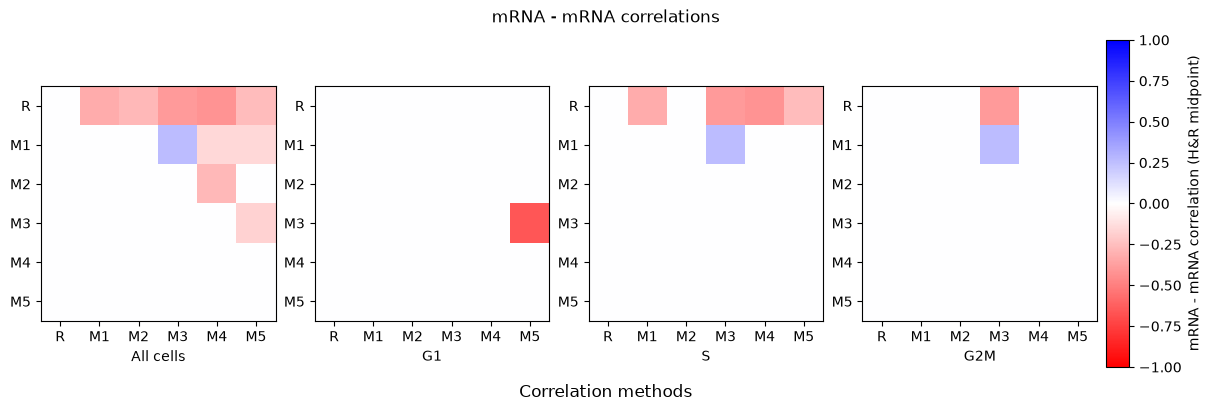

In [73]:
cmap = LinearSegmentedColormap.from_list('a', ['red', 'white', 'blue'])
fig, axs = plt.subplots(1, 5, figsize=(12, 4), gridspec_kw={'width_ratios': [1, 1, 1, 1, 0.1]}, constrained_layout=True)
im = axs[0].imshow(all_matrix, cmap=cmap, vmin=-1, vmax=1)
im = axs[1].imshow(G1_matrix, cmap=cmap, vmin=-1, vmax=1)
im = axs[2].imshow(S_matrix, cmap=cmap, vmin=-1, vmax=1)
im = axs[3].imshow(G2M_matrix, cmap=cmap, vmin=-1, vmax=1)
axs[0].set_xlabel("All cells")
axs[1].set_xlabel("G1")
axs[2].set_xlabel("S")
axs[3].set_xlabel("G2M")
RNA_labels = ["R"] + [f"M{i + 1}" for i in range(T - 1)]
for i in range(4):
    axs[i].set_xticks(range(T))
    axs[i].set_xticklabels(RNA_labels)
    axs[i].set_yticks(range(T))
    axs[i].set_yticklabels(RNA_labels)
fig.supxlabel("Correlation methods")
fig.suptitle("mRNA - mRNA correlations")
plt.colorbar(im, cax=axs[4], label="mRNA - mRNA correlation (H&R midpoint)")
plt.show()